In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader

print("Libraries imported.")


Libraries imported.


In [ ]:
# Training constants
BATCH_SIZE = 128
N_EPOCH = 20
N_CLASSES = 10
VERBOSE = 1
VALIDATION_SPLIT = 0.2

print("Main variables initialised.")

Main variables initialised.


In [ ]:
# CIFAR-10 image properties
IMG_CHANNELS = 3
IMG_ROWS = 32
IMG_COLS = 32

print("Image variables initialisation")

Image variables initialisation


In [ ]:
# CIFAR-10 dataset loading and transformation

transform_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_baseline)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_baseline)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader  = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

print("Baseline dataset loaded.")

Baseline dataset loaded.


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


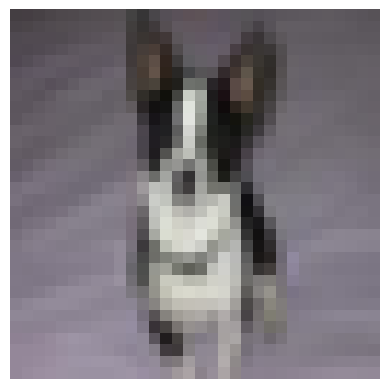

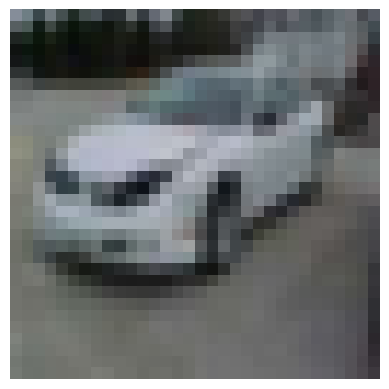

In [ ]:
classes = trainset.classes
print("Classes:", classes)

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(images[2])
imshow(images[3])

In [ ]:
dataset_size = len(trainset)
val_size = int(VALIDATION_SPLIT * dataset_size)
train_size = dataset_size - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    trainset, [train_size, val_size])

trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valloader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train/Validation split done.")

Train/Validation split done.


In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_acc, val_acc = [], []

for epoch in range(N_EPOCH):
    model.train()
    correct, total = 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = correct / total
    train_acc.append(train_accuracy)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch+1}/{N_EPOCH} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

Epoch 1/20 | Train Acc: 0.4889 | Val Acc: 0.5693
Epoch 2/20 | Train Acc: 0.6306 | Val Acc: 0.6460
Epoch 3/20 | Train Acc: 0.6894 | Val Acc: 0.6785
Epoch 4/20 | Train Acc: 0.7334 | Val Acc: 0.7048
Epoch 5/20 | Train Acc: 0.7718 | Val Acc: 0.7079
Epoch 6/20 | Train Acc: 0.8084 | Val Acc: 0.7115
Epoch 7/20 | Train Acc: 0.8469 | Val Acc: 0.7197
Epoch 8/20 | Train Acc: 0.8804 | Val Acc: 0.7108
Epoch 9/20 | Train Acc: 0.9111 | Val Acc: 0.7202
Epoch 10/20 | Train Acc: 0.9429 | Val Acc: 0.7206
Epoch 11/20 | Train Acc: 0.9621 | Val Acc: 0.7171
Epoch 12/20 | Train Acc: 0.9745 | Val Acc: 0.7133
Epoch 13/20 | Train Acc: 0.9821 | Val Acc: 0.6990
Epoch 14/20 | Train Acc: 0.9841 | Val Acc: 0.7043
Epoch 15/20 | Train Acc: 0.9836 | Val Acc: 0.7071
Epoch 16/20 | Train Acc: 0.9869 | Val Acc: 0.7067
Epoch 17/20 | Train Acc: 0.9849 | Val Acc: 0.7077
Epoch 18/20 | Train Acc: 0.9854 | Val Acc: 0.7086
Epoch 19/20 | Train Acc: 0.9851 | Val Acc: 0.7021
Epoch 20/20 | Train Acc: 0.9903 | Val Acc: 0.7015


Baseline Test Accuracy: 70.14%


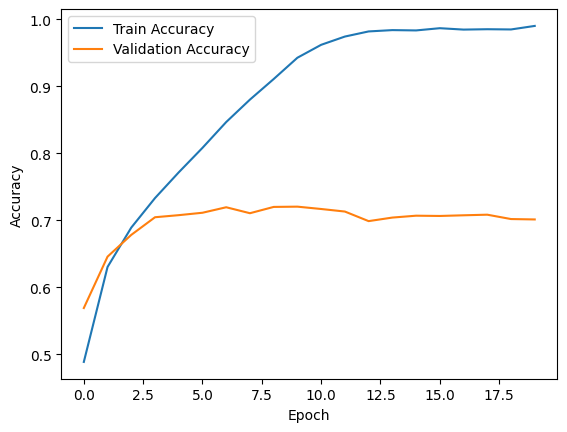

In [ ]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Baseline Test Accuracy: {test_accuracy:.2f}%")

plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
from torch.utils.data import DataLoader

train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop(32, scale=(0.85, 1.0)),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

test_transform_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=train_transform_aug)

test_dataset_aug = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=test_transform_aug)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=BATCH_SIZE, shuffle=False)

print("Augmented dataset with RandomResizedCrop loaded.")

Augmented dataset with RandomResizedCrop loaded.


In [ ]:
model_aug = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=0.001)

train_acc_aug, val_acc_aug = [], []

for epoch in range(N_EPOCH):
    model_aug.train()
    correct, total = 0, 0

    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = correct / total
    train_acc_aug.append(train_accuracy)

    # Validation on original validation loader
    model_aug.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_aug(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    val_acc_aug.append(val_accuracy)

    print(f"Epoch {epoch+1}/{N_EPOCH} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

Epoch 1/20 | Train Acc: 0.4650 | Val Acc: 0.5636
Epoch 2/20 | Train Acc: 0.5868 | Val Acc: 0.6300
Epoch 3/20 | Train Acc: 0.6330 | Val Acc: 0.6832
Epoch 4/20 | Train Acc: 0.6577 | Val Acc: 0.7155
Epoch 5/20 | Train Acc: 0.6807 | Val Acc: 0.7206
Epoch 6/20 | Train Acc: 0.6936 | Val Acc: 0.7439
Epoch 7/20 | Train Acc: 0.7117 | Val Acc: 0.7505
Epoch 8/20 | Train Acc: 0.7256 | Val Acc: 0.7683
Epoch 9/20 | Train Acc: 0.7341 | Val Acc: 0.7806
Epoch 10/20 | Train Acc: 0.7462 | Val Acc: 0.7862
Epoch 11/20 | Train Acc: 0.7525 | Val Acc: 0.7991
Epoch 12/20 | Train Acc: 0.7582 | Val Acc: 0.8091
Epoch 13/20 | Train Acc: 0.7668 | Val Acc: 0.8209
Epoch 14/20 | Train Acc: 0.7757 | Val Acc: 0.8266
Epoch 15/20 | Train Acc: 0.7783 | Val Acc: 0.8235
Epoch 16/20 | Train Acc: 0.7870 | Val Acc: 0.8289
Epoch 17/20 | Train Acc: 0.7911 | Val Acc: 0.8443
Epoch 18/20 | Train Acc: 0.7922 | Val Acc: 0.8474
Epoch 19/20 | Train Acc: 0.8018 | Val Acc: 0.8513
Epoch 20/20 | Train Acc: 0.8059 | Val Acc: 0.8603


Augmented Test Accuracy (ResizedCrop): 77.16%


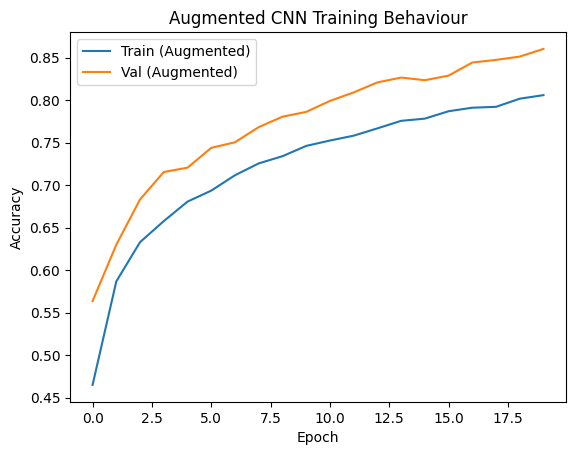

In [ ]:
# Augmented Test Accuracy
model_aug.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader_aug:
        images, labels = images.to(device), labels.to(device)
        outputs = model_aug(images)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy_aug = 100 * correct / total
print(f"Augmented Test Accuracy (ResizedCrop): {test_accuracy_aug:.2f}%")

# Augmented Training Curve
plt.figure()
plt.plot(train_acc_aug, label='Train (Augmented)')
plt.plot(val_acc_aug, label='Val (Augmented)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Augmented CNN Training Behaviour")
plt.show()

In [ ]:
train_dataset_lr = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_baseline)

test_dataset_lr = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform_baseline)

train_loader_lr = DataLoader(train_dataset_lr, batch_size=BATCH_SIZE, shuffle=True)
test_loader_lr  = DataLoader(test_dataset_lr, batch_size=BATCH_SIZE, shuffle=False)

print("Learning-rate experiment dataset loaded (no augmentation).")

Learning-rate experiment dataset loaded (no augmentation).


In [ ]:
model_lr = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lr.parameters(), lr=0.0005)

train_acc_lr, val_acc_lr = [], []

for epoch in range(N_EPOCH):
    model_lr.train()
    correct, total = 0, 0

    for images, labels in train_loader_lr:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_lr(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = correct / total
    train_acc_lr.append(train_accuracy)

    # Validation on original validation loader
    model_lr.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_lr(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    val_acc_lr.append(val_accuracy)

    print(f"Epoch {epoch+1}/{N_EPOCH} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

Epoch 1/20 | Train Acc: 0.4615 | Val Acc: 0.5541
Epoch 2/20 | Train Acc: 0.5920 | Val Acc: 0.6332
Epoch 3/20 | Train Acc: 0.6486 | Val Acc: 0.6764
Epoch 4/20 | Train Acc: 0.6896 | Val Acc: 0.7061
Epoch 5/20 | Train Acc: 0.7214 | Val Acc: 0.7480
Epoch 6/20 | Train Acc: 0.7463 | Val Acc: 0.7861
Epoch 7/20 | Train Acc: 0.7736 | Val Acc: 0.8126
Epoch 8/20 | Train Acc: 0.7971 | Val Acc: 0.8438
Epoch 9/20 | Train Acc: 0.8221 | Val Acc: 0.8490
Epoch 10/20 | Train Acc: 0.8460 | Val Acc: 0.8781
Epoch 11/20 | Train Acc: 0.8684 | Val Acc: 0.8963
Epoch 12/20 | Train Acc: 0.8895 | Val Acc: 0.9243
Epoch 13/20 | Train Acc: 0.9112 | Val Acc: 0.9356
Epoch 14/20 | Train Acc: 0.9295 | Val Acc: 0.9327
Epoch 15/20 | Train Acc: 0.9463 | Val Acc: 0.9675
Epoch 16/20 | Train Acc: 0.9616 | Val Acc: 0.9781
Epoch 17/20 | Train Acc: 0.9711 | Val Acc: 0.9823
Epoch 18/20 | Train Acc: 0.9786 | Val Acc: 0.9842
Epoch 19/20 | Train Acc: 0.9841 | Val Acc: 0.9897
Epoch 20/20 | Train Acc: 0.9876 | Val Acc: 0.9852


Lower LR Test Accuracy (lr = 0.0005): 71.66%


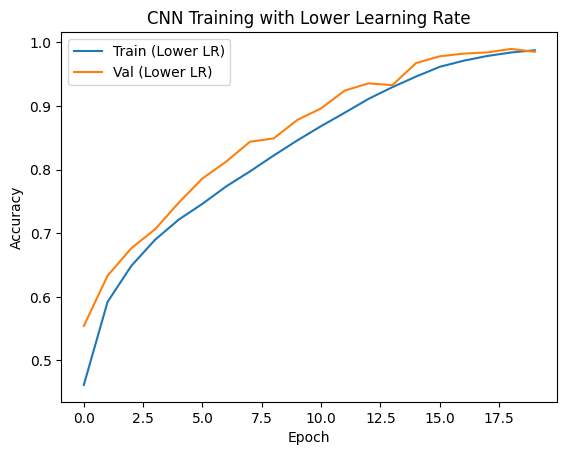

In [ ]:
model_lr.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader_lr:
        images, labels = images.to(device), labels.to(device)
        outputs = model_lr(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy_lr = 100 * correct / total
print(f"Lower LR Test Accuracy (lr = 0.0005): {test_accuracy_lr:.2f}%")

# Learning-rate-only training curve
plt.figure()
plt.plot(train_acc_lr, label='Train (Lower LR)')
plt.plot(val_acc_lr, label='Val (Lower LR)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Training with Lower Learning Rate")
plt.show()